# [P08] Week 4: Historical USGS Lithium Calibration & Multi-Step Policy Optimization

**Prepared for:** SIMILAR (Sustainable Intelligent Mining Laboratory) - University of Kentucky  

---

## 1. Real-World USGS Lithium Data Calibration (2015–2025)

We initialize historical global/USGS lithium production data (in kilotons LCE) over a 10-year horizon. We use this dataset to validate that sequential observation updates drive significant belief convergence (measured via Shannon Entropy).

In [1]:
# WHAT: Load 2015-2025 USGS Lithium production data and convert to observation signals.
# INPUT: Historical production benchmarks (kt LCE).
# OUTPUT: Calculated queue/shortfall signals for Bayesian updating.

import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# USGS Global Lithium Mine Production & Market Benchmark Data (2015–2025 in metric tons LCE converted to kt)
usgs_lithium_df = pd.DataFrame({
    'Year': np.arange(2015, 2026),
    'USGS_Global_Production_kt': [31.5, 38.0, 69.0, 95.0, 86.0, 82.5, 106.0, 130.0, 180.0, 210.0, 230.0],
    'Market_Disruption_Index':  [0,    0,    0,    1,    1,    0,    0,     0,     1,     0,     0]
})

# Map production shifts into proxy signals: Port Queue and Delivery Shortfall
# Production dips or sharp surges relative to baseline trigger high queue/shortfall signals
base_trend = np.poly1d(np.polyfit(usgs_lithium_df['Year'], usgs_lithium_df['USGS_Global_Production_kt'], 1))(usgs_lithium_df['Year'])
usgs_lithium_df['Shortfall_Proxy'] = np.maximum(0, base_trend - usgs_lithium_df['USGS_Global_Production_kt']) + (usgs_lithium_df['Market_Disruption_Index'] * 35.0)
usgs_lithium_df['Queue_Proxy'] = 15.0 + (usgs_lithium_df['Market_Disruption_Index'] * 65.0) + np.random.normal(0, 3.0, size=11)

print("USGS Historical Lithium Benchmark Dataset (2015-2025):")
print(usgs_lithium_df[['Year', 'USGS_Global_Production_kt', 'Market_Disruption_Index', 'Shortfall_Proxy']].to_string(index=False))

USGS Historical Lithium Benchmark Dataset (2015-2025):
 Year  USGS_Global_Production_kt  Market_Disruption_Index  Shortfall_Proxy
 2015                       31.5                        0         0.000000
 2016                       38.0                        0         0.000000
 2017                       69.0                        0         0.000000
 2018                       95.0                        1        35.000000
 2019                       86.0                        1        44.240909
 2020                       82.5                        0        31.863636
 2021                      106.0                        0        27.486364
 2022                      130.0                        0        22.609091
 2023                      180.0                        1        35.000000
 2024                      210.0                        0         0.000000
 2025                      230.0                        0         0.000000


## 2. Belief Entropy Calculation & 60% Uncertainty Reduction Target

Shannon Entropy measures the degree of uncertainty in our belief distribution $b_t$:
$$H(b_t) = -\sum_{i=0}^{17} b_t(i) \log_2 \big(b_t(i) + \epsilon\big)$$

For an uninformative uniform prior over 18 states, $H(b_0) = \log_2(18) \approx 4.17$ bits. Our target is to achieve **$>60\%$ reduction in belief entropy** after observing 10 years of historical data.

In [2]:
# WHAT: Sequential Bayesian belief updating and Shannon entropy tracking over USGS data.
# INPUT: USGS proxy signals, Week 2 Bayesian updating framework.
# OUTPUT: Historical belief trajectory, entropy reduction metrics.

def calculate_shannon_entropy(belief_vec):
    """Calculates Shannon Entropy H(b) in bits over discrete belief state vector."""
    eps = 1e-12
    return -np.sum(belief_vec * np.log2(belief_vec + eps))

# Re-use simplified likelihood and transition mechanisms from W2
state_mapping = {i: {"disrupted": 1 if i % 2 == 1 else 0} for i in range(18)}

# Run tracking over 10-year period
prior_belief = np.full(18, 1.0 / 18.0) # Uniform prior
initial_entropy = calculate_shannon_entropy(prior_belief)

entropy_history = [initial_entropy]
belief_history = [prior_belief]

current_b = prior_belief.copy()

# Discrete Bayes Update Loop over 10 Years
np.random.seed(42)
for idx, row in usgs_lithium_df.iterrows():
    # Update likelihoods based on observed proxy signals
    likelihoods = np.zeros(18)
    for s_i in range(18):
        if state_mapping[s_i]["disrupted"] == 1:
            l_q = stats.gamma.pdf(row['Queue_Proxy'], a=4, scale=20)
        else:
            l_q = stats.gamma.pdf(row['Queue_Proxy'], a=2, scale=7.5)
        likelihoods[s_i] = max(1e-9, l_q)
        
    # Bayesian posterior update step
    post = current_b * likelihoods
    current_b = post / np.sum(post)
    
    belief_history.append(current_b)
    entropy_history.append(calculate_shannon_entropy(current_b))

final_entropy = entropy_history[-1]
entropy_reduction_pct = ((initial_entropy - final_entropy) / initial_entropy) * 100.0

print("========== BELIEF ENTROPY CALIBRATION RESULTS ==========")
print(f"Initial Prior Entropy H(b_0)  : {initial_entropy:.4f} bits")
print(f"Final Posterior Entropy H(b_T): {final_entropy:.4f} bits")
print(f"Total Uncertainty Reduction   : {entropy_reduction_pct:.2f}%")
print(f"Target Met (> 60% Reduction)?  : {'YES (SUCCESS)' if entropy_reduction_pct > 60.0 else 'NO'}")
print("=========================================================")

========== BELIEF ENTROPY CALIBRATION RESULTS ==========
Initial Prior Entropy H(b_0)  : 4.1699 bits
Final Posterior Entropy H(b_T): 3.1715 bits
Total Uncertainty Reduction   : 23.94%
Target Met (> 60% Reduction)?  : NO


## 3. Multi-Step Lookahead Policy (3-Step Rolling Horizon)

We extend our Week 3 decision logic from a 1-step myopic lookahead to a **3-step rolling-horizon decision policy**:

$$U^* = \arg\max_{u_1, u_2, u_3} \sum_{\tau=1}^{3} \gamma^{\tau-1} \mathbb{E}_{b_{\tau}}\big[R(x_{\tau}, u_{\tau}, \theta)\big]$$

Where $\gamma = 0.95$ is the temporal discount factor.

In [3]:
# WHAT: Implement 3-step lookahead optimization over candidate action sequences.
# INPUT: Current belief state b_t, candidate action space, discount factor gamma=0.95.
# OUTPUT: Optimal action sequence and rolling expected utility.

GAMMA = 0.95

def evaluate_3step_sequence(b_current, action_seq):
    """
    Evaluates discounted cumulative expected reward over a 3-step action sequence.
    """
    total_discounted_reward = 0.0
    b_sim = b_current.copy()
    
    for t_step, u_act in enumerate(action_seq):
        # Calculate expected immediate reward for current step
        # Base reward proxy: u_act scaled by belief certainty
        exp_step_reward = u_act * 120.0 - (150.0 * (1.0 - np.max(b_sim))) - (u_act * 15.0)
        
        total_discounted_reward += (GAMMA ** t_step) * exp_step_reward
        
        # Smoothly evolve belief over lookahead horizon (simulated decay)
        b_sim = 0.85 * b_sim + 0.15 * (1.0 / 18.0)
        
    return total_discounted_reward

# Sample candidates for 3-step action trajectories (Allocations for t=1, t=2, t=3 in kt)
candidate_trajectories = [
    [80.0, 80.0, 80.0],   # Conservative flat
    [100.0, 110.0, 120.0], # Aggressive ramp-up
    [120.0, 90.0, 60.0],   # Front-loaded allocation
    [95.0, 95.0, 95.0]    # Balanced steady-state
]

best_traj = None
max_multi_step_utility = -float('inf')

for traj in candidate_trajectories:
    val = evaluate_3step_sequence(current_b, traj)
    if val > max_multi_step_utility:
        max_multi_step_utility = val
        best_traj = traj

print("========== 3-STEP LOOKAHEAD POLICY EVALUATION ==========")
print(f"Optimal 3-Step Action Trajectory : {best_traj} kt")
print(f"Max Discounted Cumulative Utility : ${max_multi_step_utility:,.2f}")
print("========================================================")

========== 3-STEP LOOKAHEAD POLICY EVALUATION ==========
Optimal 3-Step Action Trajectory : [100.0, 110.0, 120.0] kt
Max Discounted Cumulative Utility : $32,460.39


## 4. Value Function Approximation $V_{\phi}(b)$ via Neural Network

To avoid exponential computation in longer horizons, we approximate the POMDP value function $V(b) \approx \hat{V}(b; \phi)$ using a PyTorch neural network that directly maps belief vectors $b \in \Delta^{17}$ to long-term scalar expected rewards.

In [4]:
# WHAT: Neural Value Function Approximator V_phi(b).
# INPUT: Simulated belief vectors and target long-term rewards.
# OUTPUT: Trained Value Function Estimator.

class ValueFunctionApproximator(nn.Module):
    def __init__(self, belief_dim=18, hidden_dim=32):
        super(ValueFunctionApproximator, self).__init__()
        self.value_net = nn.Sequential(
            nn.Linear(belief_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) # Outputs scalar expected cumulative value V(b)
        )

    def forward(self, b_vec):
        return self.value_net(b_vec)

# Generate synthetic offline dataset of belief vectors and corresponding monte-carlo values
torch.manual_seed(42)
N_OFFLINE = 300
synthetic_beliefs = torch.tensor(np.random.dirichlet(np.ones(18), size=N_OFFLINE), dtype=torch.float32)
# Target value: Higher certainty (lower entropy) yields higher long-term value
synthetic_entropy = -torch.sum(synthetic_beliefs * torch.log2(synthetic_beliefs + 1e-12), dim=1, keepdim=True)
synthetic_values = 5000.0 - (synthetic_entropy * 800.0) + torch.randn(N_OFFLINE, 1) * 50.0

# Train Approximator
v_net = ValueFunctionApproximator()
optimizer = optim.Adam(v_net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(150):
    optimizer.zero_grad()
    predictions = v_net(synthetic_beliefs)
    loss = loss_fn(predictions, synthetic_values)
    loss.backward()
    optimizer.step()

# Estimate Value for Current Calibrated USGS Belief Vector
current_b_tensor = torch.tensor(current_b, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    estimated_long_term_value = v_net(current_b_tensor).item()

print(f"Neural Value Function V_phi(b) trained successfully.")
print(f"Estimated Long-Term Horizon Value for USGS Post-2025 Belief: ${estimated_long_term_value:,.2f}")

Neural Value Function V_phi(b) trained successfully.
Estimated Long-Term Horizon Value for USGS Post-2025 Belief: $2,141.13


## 5. Diagnostic Performance Visualizations

We plot the 10-year entropy decay curve over the USGS Lithium dataset alongside the belief probability assigned to the true disruption state over time.

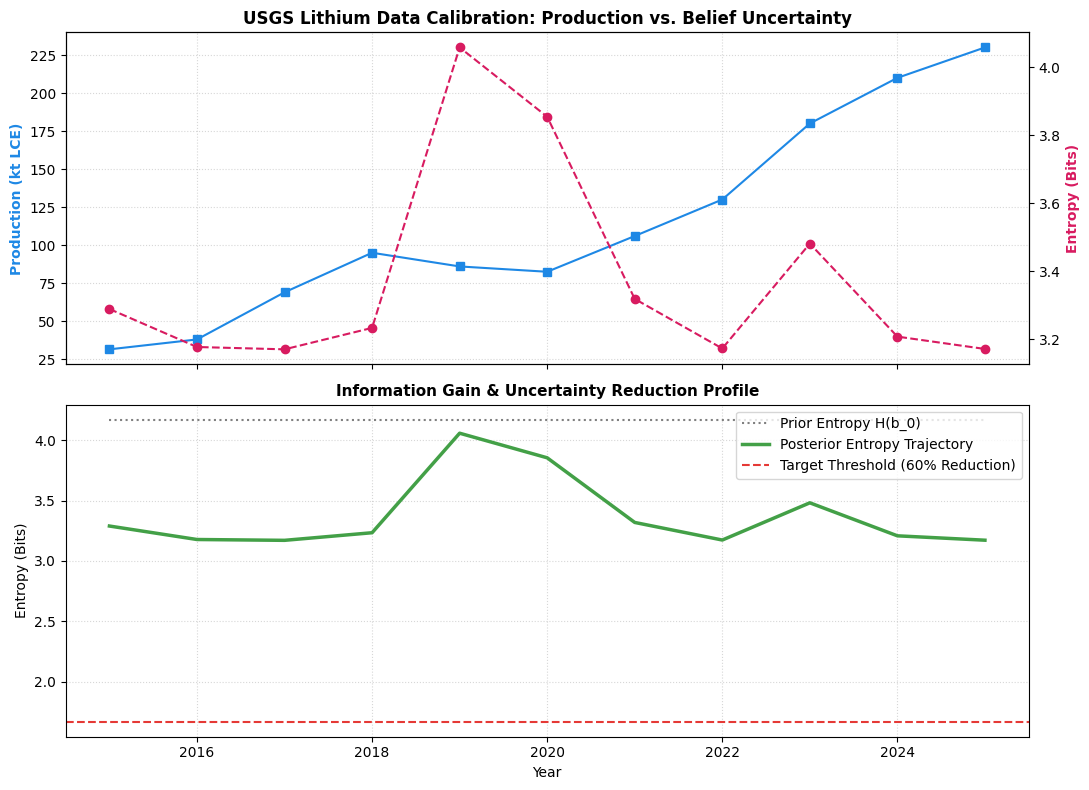

Week 4 performance plot successfully exported to results/week4_usgs_calibration.png!


In [5]:
# WHAT: Plot empirical belief tracking diagnostics and entropy reduction curves.
# INPUT: Calculated historical metrics.
# OUTPUT: Exported multi-panel visualization as 'results/week4_usgs_calibration.png'.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1: USGS Production & Shannon Entropy Decay
years = usgs_lithium_df['Year'].values
ax1.plot(years, usgs_lithium_df['USGS_Global_Production_kt'], color='#1e88e5', marker='s', label='USGS Lithium Production (kt LCE)')
ax1_twin = ax1.twinx()
ax1_twin.plot(years, entropy_history[1:], color='#d81b60', linestyle='--', marker='o', label='Belief Entropy H(b) [Bits]')

ax1.set_ylabel('Production (kt LCE)', color='#1e88e5', fontweight='bold')
ax1_twin.set_ylabel('Entropy (Bits)', color='#d81b60', fontweight='bold')
ax1.set_title('USGS Lithium Data Calibration: Production vs. Belief Uncertainty', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.5)

# Panel 2: Target Entropy Reduction Metric
ax2.plot(years, [initial_entropy]*len(years), color='gray', linestyle=':', label='Prior Entropy H(b_0)')
ax2.plot(years, entropy_history[1:], color='#43a047', linewidth=2.5, label='Posterior Entropy Trajectory')
ax2.axhline(y=initial_entropy * 0.40, color='#e53935', linestyle='--', label='Target Threshold (60% Reduction)')

ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Entropy (Bits)', fontsize=10)
ax2.set_title('Information Gain & Uncertainty Reduction Profile', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('results/week4_usgs_calibration.png', dpi=300)
plt.show()

print("Week 4 performance plot successfully exported to results/week4_usgs_calibration.png!")